In [1]:
!pip install pandas

In [5]:
import pandas as pd
import sqlite3
from sqlite3 import Error
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("ab-test.csv")

before = pd.DataFrame()
before_test= df[(df["time"] == "before") & (df["group"] == "test")]["diff"]
before_control = df[(df["time"] == "before") & (df["group"] == "control")]["diff"]

after = df[df["time"] == "after"]
after_test= df[(df["time"] == "after") & (df["group"] == "test")]["diff"]
after_control = df[(df["time"] == "after") & (df["group"] == "control")]["diff"]



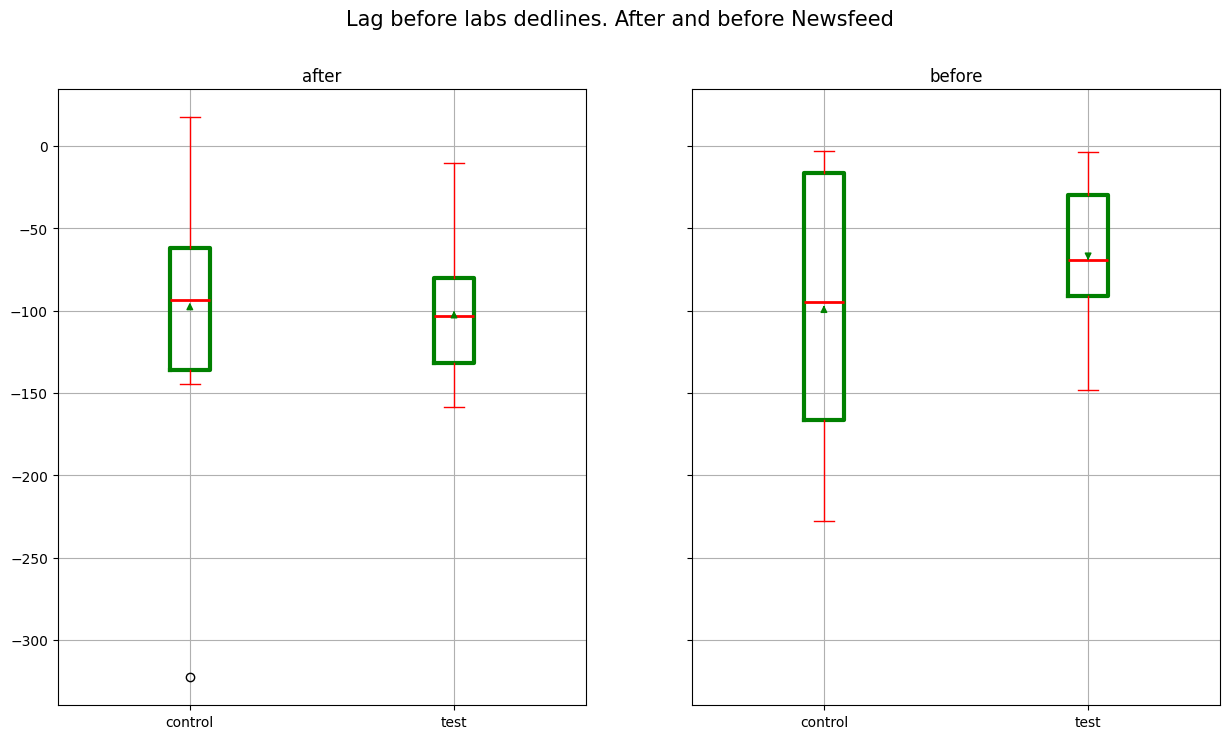

In [7]:
fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,8), sharey=True)

box_1 = ax1.boxplot([after_control, after_test], 
                    tick_labels=["control", "test"],
                    whiskerprops={'color': 'red'}, 
                    capprops={'color': 'red'},
                    boxprops={"color": "green","linewidth": 3}, 
                    medianprops={"color": "red","linewidth": 2},
                    )
ax1.set_title("after")
ax1.grid()
ax1.annotate(text= "", xy=(1, after_control.median()), xytext=(1, -100), ha='center', color="green",  arrowprops=dict(arrowstyle='-|>',
                                                                                                                       facecolor='green',            
                                                                                                                       edgecolor='green'))
                         
ax1.annotate(text= "", xy=(2, -100), xytext=(2, after_test.median()), ha='center', color="green", arrowprops=dict(arrowstyle='-|>',
                                                                                                                       facecolor='green',            
                                                                                                                       edgecolor='green'))

box_2 = ax2.boxplot([before_control, before_test], 
                    tick_labels=["control", "test"], 
                    whiskerprops={'color': 'red'},
                    capprops={'color': 'red'},
                    boxprops={"color": "green", "linewidth": 3}, 
                    medianprops={"color": "red", "linewidth": 2},
                    )
ax2.set_title("before")
ax2.grid()
ax2.annotate(text= "", xytext=(1, -100), xy=(1, before_control.median()), ha='center', color="green", arrowprops=dict(arrowstyle='-|>',
                                                                                                                       facecolor='green',            
                                                                                                                       edgecolor='green'))
ax2.annotate(text= "", xytext=(2, before_test.median() +1), xy=(2, before_test.median()), ha='center', color="green", arrowprops=dict(arrowstyle='-|>',
                                                                                                                       facecolor='green',            
                                                                                                                       edgecolor='green'))


plt.suptitle("Lag before labs dedlines. After and before Newsfeed", fontsize=15)
plt.show()

#### What was the IQR of the control group before the newsfeed? 150